# hftbacktest - TW Stock

Refactored notebook for Taiwan stock L2 backtest experiments.


## Setup

Set the symbol and time range, convert L2 data to hftbacktest events, then build shared backtest config.


In [ ]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from scripts.tw_stock_data_to_npz import convert_tw_stock_to_npz
from scripts.tw_stock_hftbacktest import BacktestConfig, import_hftbacktest
from scripts.tw_stock_strategies import (
    DEFAULT_QUEUE_MODELS,
    run_aggressive_fill_strategy,
    run_queue_model_comparison,
    run_level_queue_model_comparison,
)


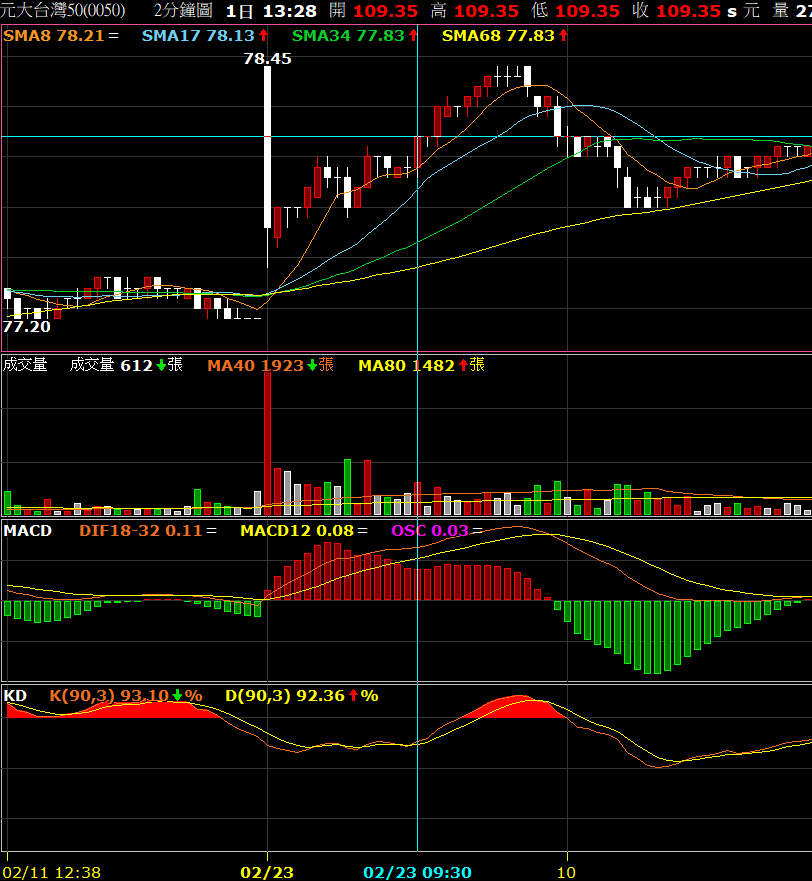

In [ ]:
SYMBOL = "0050"
START_DATE = "2026-02-23"
END_DATE = START_DATE
START_TIME = "09:30:00"
END_TIME = "10:00:00"

DATA_FILE, event_data = convert_tw_stock_to_npz(
    symbol=SYMBOL,
    start_date=START_DATE,
    end_date=END_DATE,
    start_time=START_TIME,
    end_time=END_TIME,
    workspace_root=ROOT,
)

hbtpkg = import_hftbacktest(ROOT)
TICK_SIZE = 0.05
CONFIG = BacktestConfig(data=DATA_FILE, order_latency_ns=0, tick_size=TICK_SIZE)
QUEUE_MODELS = DEFAULT_QUEUE_MODELS
DATA_FILE, TICK_SIZE


## Strategy 1: Aggressive Fill at BBO

Buy at best ask, then sell at best bid. This should fill immediately by design.


In [ ]:
strategy1_output = run_aggressive_fill_strategy(
    CONFIG,
    hbtpkg,
    event_data,
    qty=1.0,
    round_trips=1,
)
strategy1_summary = strategy1_output[
    [
        "label", "side", "order_id", "price", "exec_price", "exec_qty",
        "send_order_time", "fill_time", "position", "balance", "equity",
        "num_trades", "trading_volume", "trading_value",
    ]
]
strategy1_summary


## Strategy 2: Passive Bid1/Ask1 Queue Model Comparison

Submit passive buy at bid1 and passive sell at ask1. Compare fill timestamps across queue models.


In [ ]:
strategy2_output, strategy2_fill_comparison = run_queue_model_comparison(
    CONFIG,
    hbtpkg,
    event_data,
    queue_models=QUEUE_MODELS,
    qty=1.0,
)
strategy2_summary = strategy2_fill_comparison[
    [
        "queue_model", "side", "order_id", "price", "exec_price", "exec_qty",
        "send_order_time", "fill_time", "time_to_fill_s", "queue_model_fill_delta_ns",
        "position", "balance", "equity",
    ]
]
strategy2_summary


## Strategy 3: Passive Sell5 on Sampled Uptrend

Submit one passive order at a fixed book level, e.g. `sell5`, with larger quantity and a longer observation window. This keeps the test simple and targets the sampled uptrend segment directly.


In [ ]:
strategy3_output, strategy3_comparison = run_level_queue_model_comparison(
    CONFIG,
    hbtpkg,
    event_data,
    queue_models=QUEUE_MODELS,
    side="sell",
    level=5,
    qty=3.0,
    max_window_s=6 * 60 * 60,
)
strategy3_summary = strategy3_comparison[
    [
        "queue_model", "side", "level", "actual_level", "price", "qty",
        "send_best_bid", "send_best_ask", "send_order_time", "fill_time", "was_filled",
        "time_to_fill_s", "queue_model_fill_delta_ns", "fill_step", "exec_price", "exec_qty",
        "position", "balance", "equity",
    ]
]
strategy3_summary
